# PHQ-8 Depression Detection — CNN + Bidirectional LSTM (Regression)

**Architecture**: 2 convolutional blocks reduce the frequency axis while preserving the time axis, producing a sequence of CNN feature vectors that is fed into a 1-layer bidirectional LSTM. All 200 BiLSTM output steps are aggregated via learned temporal attention into a single context vector, which is passed to an FC regression head.

**Motivation**: Replaces the unidirectional LSTM in `cnn_lstm.ipynb` with a bidirectional LSTM. Each time step's representation is formed by concatenating a forward pass (past context) and a backward pass (future context), giving the model access to the full temporal context of the segment when encoding each frame.

**Input**: log-mel spectrograms `(1, 128, 801)` saved as `.npy` files.

**Target**: PHQ-8 score (continuous, 0–24).

**Sequence flow**:
```
(B, 1, 128, 801)
  → CNN blocks      → (B, 32, 16, 200)
  → reshape         → (B, 200, 512)       # 200 time steps, 512 features each
  → BiLSTM (1L)     → outputs (B, 200, 128)  # 64 forward + 64 backward
  → attention       → context (B, 128)    # weighted sum over 200 steps
  → FC head         → (B,)
```

## 1. Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [3]:
# Paths
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "processed"
META_CSV = PROCESSED_DIR / "segment_metadata.csv"
SPEC_ROOT = PROCESSED_DIR / "spectrograms"
SAVE_DIR = BASE_DIR / "experiments" / "best_model" / "cnn_bilstm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Training hyper-parameters
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3
CHECKPOINT_FREQ = 10
EARLY_STOPPING_PATIENCE = 10
NUM_WORKERS = 0

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cpu":
    print("  WARNING: No GPU detected — training will be significantly slower.")
print(f"Checkpoints will be saved to: {SAVE_DIR.resolve()}")

Using device: cuda
Checkpoints will be saved to: C:\Users\edgar\OneDrive\Documents\Term_8\Deep_learning\Project\phq8_depression_detection\experiments\best_model\cnn_bilstm


## 2. Dataset

In [4]:
def spec_augment(spec, n_freq_masks=2, freq_mask_width=10, n_time_masks=2, time_mask_width=50):
    """
    SpecAugment: randomly zero-out horizontal (frequency) and vertical (time)
    bands of a spectrogram.  Applied in-place on a (n_mels, n_frames) tensor.
    """
    n_mels, n_frames = spec.shape
    for _ in range(n_freq_masks):
        f = torch.randint(0, freq_mask_width + 1, (1,)).item()
        f0 = torch.randint(0, max(n_mels - f, 1), (1,)).item()
        spec[f0 : f0 + f, :] = 0.0
    for _ in range(n_time_masks):
        t = torch.randint(0, time_mask_width + 1, (1,)).item()
        t0 = torch.randint(0, max(n_frames - t, 1), (1,)).item()
        spec[:, t0 : t0 + t] = 0.0
    return spec

class SpectrogramDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, spec_root: Path, split: str):
        self.meta = meta_df.reset_index(drop=True)
        self.split_dir = spec_root / split
        self.augment = (split == "train")

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        pid = int(row["participant_id"])
        seg = int(row["segment_idx"])
        spec_path = self.split_dir / f"{pid}_seg{seg:04d}.npy"
        spec = np.load(spec_path).astype(np.float32)
        spec = torch.from_numpy(spec)                        # (128, n_frames)
        if self.augment:
            spec = spec_augment(spec)
        spec = spec.unsqueeze(0)                             # (1, 128, n_frames)
        label = torch.tensor(float(row["phq_score"]), dtype=torch.float32)
        pid_t = torch.tensor(pid, dtype=torch.long)
        return spec, label, pid_t

def build_loaders(meta_csv, spec_root, batch_size, num_workers):
    meta = pd.read_csv(meta_csv)
    splits = {}
    for split in ("train", "dev", "test"):
        df = meta[meta["split"] == split].reset_index(drop=True)
        ds = SpectrogramDataset(df, spec_root, split)
        splits[split] = DataLoader(
            ds, batch_size=batch_size, shuffle=(split == "train"),
            num_workers=num_workers, pin_memory=True
        )
        display_name = "validation" if split == "dev" else split
        aug_str = " + SpecAugment" if ds.augment else ""
        print(f"  {display_name:10s}: {len(df):6,} segments{aug_str}  →  {ds.split_dir}")
    return splits

print("Building data loaders…")
loaders      = build_loaders(META_CSV, SPEC_ROOT, BATCH_SIZE, NUM_WORKERS)
train_loader = loaders["train"]
val_loader   = loaders["dev"]
test_loader  = loaders["test"]

Building data loaders…
  train     : 11,362 segments + SpecAugment  →  ..\processed\spectrograms\train
  validation:  4,322 segments  →  ..\processed\spectrograms\dev
  test      :  5,904 segments  →  ..\processed\spectrograms\test


## 3. Model — CNN Feature Extractor + Bidirectional LSTM with Temporal Attention

Key difference from `cnn_lstm.ipynb`: the LSTM is replaced with a **bidirectional LSTM**.
- The forward pass encodes left-to-right context; the backward pass encodes right-to-left context.
- At each time step the two hidden states are concatenated, doubling the output dimension to `lstm_hidden * 2`.
- The attention layer and FC head are updated accordingly to accept `lstm_hidden * 2` features.

In [5]:
class CNNBiLSTMRegressor(nn.Module):
    """
    CNN feature extractor + bidirectional LSTM + temporal attention for PHQ-8 regression.

    The CNN collapses the frequency axis while preserving 200 time steps.
    The BiLSTM processes the resulting sequence in both directions; all 200
    output vectors (forward + backward concatenated) are aggregated via a
    learned attention mechanism, giving the model full bidirectional temporal
    context for each segment.

    Tensor flow
    -----------
    Input     : (B, 1, 128, 801)    — log-mel spectrogram
    Block 1   : MaxPool2d(2,2)   →  (B, 16, 64, 400)
    Block 2   : MaxPool2d(4,2)   →  (B, 32, 16, 200)
    Reshape   :                  →  (B, 200, 512)       # T=200, feat=32×16
    BiLSTM(1L):                  →  outputs (B, 200, 128)  # 64 fwd + 64 bwd
    Attention :                  →  context (B, 128)    # weighted sum over T
    FC head   :                  →  (B,)
    """

    def __init__(self, lstm_hidden: int = 64, lstm_layers: int = 1, dropout: float = 0.5):
        super().__init__()

        # ── CNN blocks ────────────────────────────────────────────────────
        self.cnn = nn.Sequential(
            # Block 1: (B, 1, 128, 801) → (B, 16, 64, 400)
            nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)),
            # Block 2: (B, 16, 64, 400) → (B, 32, 16, 200)
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(4, 2), stride=(4, 2)),
        )
        cnn_feat = 32 * 16  # 512

        # ── Bidirectional LSTM ────────────────────────────────────────────
        # bidirectional=True concatenates forward & backward hidden states,
        # so each output vector has size lstm_hidden * 2.
        self.lstm = nn.LSTM(
            input_size=cnn_feat,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
        )
        lstm_out_size = lstm_hidden * 2  # 128

        # ── Temporal attention ────────────────────────────────────────────
        self.attn = nn.Linear(lstm_out_size, 1, bias=False)

        # ── FC regression head ────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_size, 1),
        )

    def forward(self, x):
        # x: (B, 1, 128, 801)
        x = self.cnn(x)                         # (B, 32, 16, 200)
        B, C, F, T = x.shape
        x = x.permute(0, 3, 1, 2)              # (B, T, C, F)
        x = x.reshape(B, T, C * F)             # (B, T, 512)

        outputs, _ = self.lstm(x)               # outputs: (B, T, lstm_hidden*2)

        # Temporal attention: score every time step, normalise, weighted sum
        scores  = self.attn(outputs)            # (B, T, 1)
        weights = torch.softmax(scores, dim=1)  # (B, T, 1)
        context = (weights * outputs).sum(dim=1)  # (B, lstm_hidden*2)

        out = self.head(context)                # (B, 1)
        return out.squeeze(1)                   # (B,)


model = CNNBiLSTMRegressor(lstm_hidden=64, lstm_layers=1, dropout=0.5).to(DEVICE)

with torch.no_grad():
    dummy = torch.zeros(2, 1, 128, 801, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape: {out.shape}  (expected: (2,))")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Output shape: torch.Size([2])  (expected: (2,))
Trainable parameters: 301,041


## 4. Training Loop

In [6]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {"train_loss": [], "val_loss": [], "val_rmse": []}
best_val_loss = float("inf")
epochs_no_improve = 0


def train_epoch(loader):
    """Segment-level training pass."""
    model.train()
    total_loss, total_samples = 0.0, 0
    for specs, labels, _ in loader:
        specs  = specs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        preds  = model(specs)
        loss   = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * len(labels)
        total_samples += len(labels)
    return total_loss / total_samples


def evaluate_participant(loader):
    """
    Participant-level evaluation.
    Runs inference on every segment, then averages each participant's
    segment predictions into one score before computing metrics.
    """
    model.eval()
    records = []
    with torch.no_grad():
        for specs, labels, pids in loader:
            specs = specs.to(DEVICE, non_blocking=True)
            preds = model(specs).cpu().numpy()
            for pid, pred, label in zip(pids.numpy(), preds, labels.numpy()):
                records.append((int(pid), float(pred), float(label)))

    df = pd.DataFrame(records, columns=["participant_id", "pred", "label"])
    agg = df.groupby("participant_id").agg(
        pred  = ("pred",  "mean"),
        label = ("label", "first"),
    ).reset_index()

    mse  = float(np.mean((agg["pred"].values - agg["label"].values) ** 2))
    rmse = mse ** 0.5
    return mse, rmse, agg


for epoch in range(1, NUM_EPOCHS + 1):

    train_mse = train_epoch(train_loader)
    val_mse, val_rmse, _ = evaluate_participant(val_loader)

    history["train_loss"].append(train_mse)
    history["val_loss"].append(val_mse)
    history["val_rmse"].append(val_rmse)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}], Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}, Val RMSE: {val_rmse:.4f}")

    # Checkpoint
    if epoch % CHECKPOINT_FREQ == 0:
        ckpt_path = SAVE_DIR / f"epoch{epoch}_cnn_bilstm.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_mse":            train_mse,
            "val_mse":              val_mse,
        }, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path.name}")

    # Save best / early stopping (participant-level val MSE)
    if val_mse < best_val_loss:
        best_val_loss     = val_mse
        epochs_no_improve = 0
        best_path = SAVE_DIR / "cnn_bilstm_best.pth"
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_mse":              val_mse,
            "val_rmse":             val_rmse,
        }, best_path)
        print(f"  Best model saved -> {best_path.name}  (val MSE {val_mse:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\n  Early stopping triggered — no improvement for {EARLY_STOPPING_PATIENCE} epochs.")
            break

print("\nTraining complete.")
print(f"Best val MSE (participant) : {best_val_loss:.4f}  |  RMSE : {best_val_loss**0.5:.4f}")

Epoch [1/100], Train MSE: 34.9584, Val MSE: 44.4635, Val RMSE: 6.6681
  Best model saved -> cnn_bilstm_best.pth  (val MSE 44.4635)
Epoch [2/100], Train MSE: 28.4889, Val MSE: 43.1490, Val RMSE: 6.5688
  Best model saved -> cnn_bilstm_best.pth  (val MSE 43.1490)
Epoch [3/100], Train MSE: 27.9736, Val MSE: 42.4842, Val RMSE: 6.5180
  Best model saved -> cnn_bilstm_best.pth  (val MSE 42.4842)
Epoch [4/100], Train MSE: 27.5101, Val MSE: 42.2485, Val RMSE: 6.4999
  Best model saved -> cnn_bilstm_best.pth  (val MSE 42.2485)
Epoch [5/100], Train MSE: 26.9816, Val MSE: 43.4232, Val RMSE: 6.5896
Epoch [6/100], Train MSE: 26.4396, Val MSE: 43.3022, Val RMSE: 6.5804
Epoch [7/100], Train MSE: 25.9344, Val MSE: 44.8552, Val RMSE: 6.6974
Epoch [8/100], Train MSE: 25.4941, Val MSE: 45.4611, Val RMSE: 6.7425
Epoch [9/100], Train MSE: 24.5267, Val MSE: 47.1626, Val RMSE: 6.8675
Epoch [10/100], Train MSE: 23.8188, Val MSE: 48.6288, Val RMSE: 6.9734
  Checkpoint saved -> epoch10_cnn_bilstm.pth
Epoch [11/

## 5. Training Curves

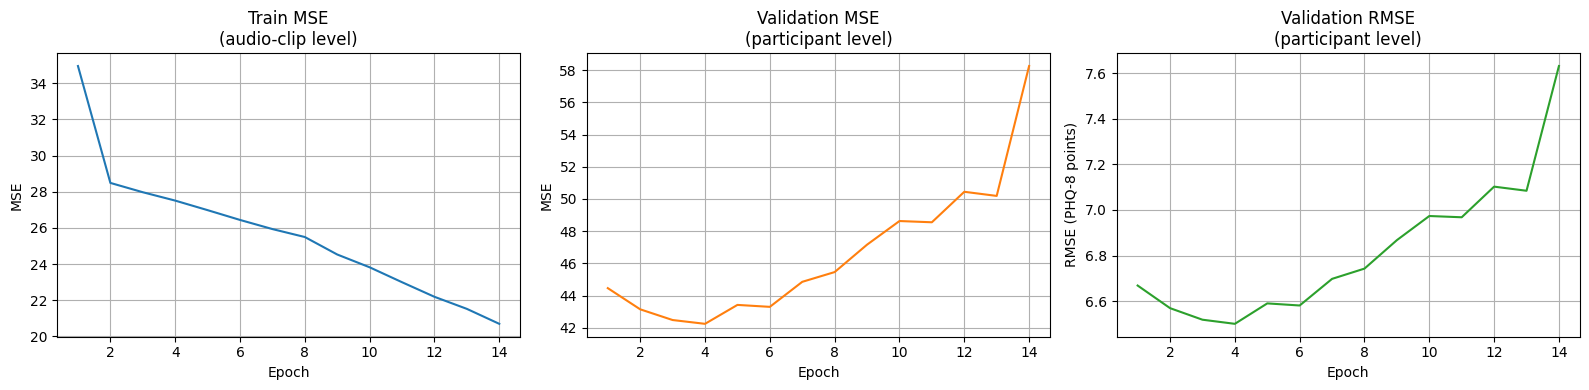

In [7]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history["train_loss"], color="tab:blue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Train MSE\n(audio-clip level)")
axes[0].grid(True)

axes[1].plot(epochs, history["val_loss"], color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")
axes[1].set_title("Validation MSE\n(participant level)")
axes[1].grid(True)

axes[2].plot(epochs, history["val_rmse"], color="tab:green")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE (PHQ-8 points)")
axes[2].set_title("Validation RMSE\n(participant level)")
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 6. Evaluation on Test Set

Loads the best checkpoint and reports participant-level MSE, RMSE, MAE, and Pearson r.
Each participant's segment predictions are averaged into a single score before computing metrics.

In [8]:
# Load best weights
best_ckpt = torch.load(SAVE_DIR / "cnn_bilstm_best.pth", map_location=DEVICE, weights_only=True)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']}  "
      f"(val MSE {best_ckpt['val_mse']:.4f})")

# Participant-level predictions on test set
_, _, test_agg = evaluate_participant(test_loader)

all_preds  = test_agg["pred"].values
all_labels = test_agg["label"].values

print(f"  Participants evaluated: {len(test_agg)}")

# Metrics
test_mse  = float(np.mean((all_preds - all_labels) ** 2))
test_rmse = test_mse ** 0.5
test_mae  = float(np.mean(np.abs(all_preds - all_labels)))
test_r, _ = pearsonr(all_preds, all_labels)

print("\n── Test-set results (participant level) ───────────")
print(f"  MSE       : {test_mse:.4f}")
print(f"  RMSE      : {test_rmse:.4f}  PHQ-8 points")
print(f"  MAE       : {test_mae:.4f}  PHQ-8 points")
print(f"  Pearson r : {test_r:.4f}")

Loaded best model from epoch 4  (val MSE 42.2485)
  Participants evaluated: 47

── Test-set results (participant level) ───────────
  MSE       : 42.4376
  RMSE      : 6.5144  PHQ-8 points
  MAE       : 5.3980  PHQ-8 points
  Pearson r : -0.0177


## 7. Prediction Distribution

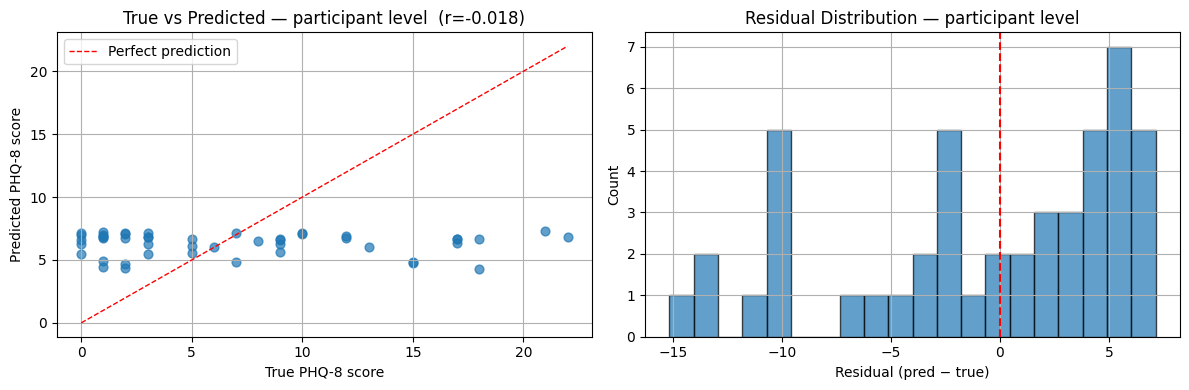

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# One point per participant
axes[0].scatter(all_labels, all_preds, alpha=0.7, s=40)
lo, hi = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
axes[0].set_xlabel("True PHQ-8 score")
axes[0].set_ylabel("Predicted PHQ-8 score")
axes[0].set_title(f"True vs Predicted — participant level  (r={test_r:.3f})")
axes[0].legend()
axes[0].grid(True)

residuals = all_preds - all_labels
axes[1].hist(residuals, bins=20, edgecolor="k", alpha=0.7)
axes[1].axvline(0, color="r", linestyle="--")
axes[1].set_xlabel("Residual (pred − true)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution — participant level")
axes[1].grid(True)

plt.tight_layout()
plt.show()